# Compare Outputs Between Base and Fine-Tuned Models
Uses Unsloth to load a fine-tuned version of Qwen 3.5 0.8B trained for binary query classification as EchoBot's guardian model.

In [2]:
%load_ext autoreload
%autoreload 2

import gc
import torch
from datasets import load_dataset
from unsloth import FastLanguageModel

import os
os.environ["HF_HUB_OFFLINE"] = "1"

from dotenv import load_dotenv
load_dotenv()
SYSTEM_PROMPT = os.getenv("SYSTEM_PROMPT") 

max_seq_length = 2048

🦥 Unsloth: Will patch your computer to enable 2x faster free finetuning.
🦥 Unsloth Zoo will now patch everything to make training faster!


# Load Dataset

In [ ]:
def formatting_func(sample):
    return {
        "prompt": (
            f"{SYSTEM_PROMPT}\n"
            f"User query: {sample['query']}\n"
            "Classification: "
        ),
        "completion": str(sample['label'])
    }

In [ ]:
train_path = "../data/overfit/train.jsonl"
val_path = "../data/echobot/val.jsonl"
test_path = "../data/overfit/train.jsonl"

dataset = load_dataset(
    "json",
    data_files={
        "train": train_path,
        "validation": val_path,
        "test": test_path,
    },
)
print(dataset['train'].features)

In [ ]:
from collections import Counter

# format dataset with only 'prompt' and 'completion' collumns
formatted_train = dataset["train"].map(
    formatting_func,
    remove_columns=dataset["train"].column_names
    )
formatted_val = dataset["validation"].map(
    formatting_func,
    remove_columns=dataset["validation"].column_names
    )
formatted_test = dataset["test"].map(
    formatting_func,
    remove_columns=dataset["test"].column_names
    )

print(Counter(formatted_train["completion"]))
print(Counter(formatted_val["completion"]))
print(Counter(formatted_test["completion"]))


# Compare Models

In [ ]:
from evaluation import evaluate_model

In [ ]:
base_model_name = "eb-base-qwen-v1"
base_model, base_tokenizer = FastLanguageModel.from_pretrained(
    model_name = "Qwen/Qwen3.5-0.8B",
    max_seq_length = max_seq_length,
    load_in_4bit = True,
    full_finetuning = False,
    dtype = torch.bfloat16,
    device_map= "auto",
)
FastLanguageModel.for_inference(base_model)

In [ ]:
evaluate_model(
    model=base_model, 
    tokenizer=base_tokenizer,
    dataset=dataset['test'],
    model_str=base_model_name,
    batch_size=16
)

In [ ]:
del base_model
del base_tokenizer

gc.collect()
torch.cuda.empty_cache()
torch.cuda.ipc_collect()

In [ ]:
lora_model_name = "eb-ovrft-lora-qwen-v1"
lora_model, lora_tokenizer = FastLanguageModel.from_pretrained(
    model_name = f"../adapters/{lora_model_name}",
    max_seq_length = max_seq_length,
    load_in_4bit = True,
    full_finetuning = False,
    dtype = torch.bfloat16,
    device_map= "auto",
)
FastLanguageModel.for_inference(lora_model)

In [ ]:
evaluate_model(
    model=lora_model, 
    tokenizer=lora_tokenizer,
    dataset=dataset['test'],
    model_str=lora_model_name,
    batch_size=16
)

# Compare outputs between different base models

In [2]:
from evaluation import evaluate_model, plot_model_metrics

In [6]:
train_path = "../data/echobot_old/train.jsonl"
val_path = "../data/echobot_old/val.jsonl"
test_path = "../data/echobot_old/test.jsonl"

dataset = load_dataset(
    "json",
    data_files={
        "train": train_path,
        "validation": val_path,
        "test": test_path,
    },
)

{'id': Value('string'), 'query': Value('string'), 'label': Value('int64'), 'source': Value('string'), 'tag': Value('string')}


In [7]:
max_seq_length = 2048

print("======== STATS FOR 0.8B PARAMETER MODEL =========")
model_08b, tokenizer_08b= FastLanguageModel.from_pretrained(
    model_name = "Qwen/Qwen3.5-0.8B",
    max_seq_length = max_seq_length,
    load_in_4bit = True,
    full_finetuning = False,
    dtype = torch.bfloat16,
    device_map= "auto",
)
evaluate_model(
    model=model_08b, 
    tokenizer=tokenizer_08b,
    dataset=dataset['test'],
    model_str="qwen35-08b-test",
    batch_size=16
)

del model_08b
del tokenizer_08b
gc.collect()
torch.cuda.empty_cache()
torch.cuda.ipc_collect()

print("\n======== STATS FOR 9B PARAMETER MODEL =========")
model_9b, tokenizer_9b= FastLanguageModel.from_pretrained(
    model_name = "unsloth/Qwen3.5-9B",
    max_seq_length = max_seq_length,
    load_in_4bit = True,
    full_finetuning = False,
    dtype = torch.bfloat16,
    device_map= "auto",
)
evaluate_model(
    model=model_9b, 
    tokenizer=tokenizer_9b,
    dataset=dataset['test'],
    model_str="qwen35-9b-test",
    batch_size=16
)

del model_9b
del tokenizer_9b
gc.collect()
torch.cuda.empty_cache()
torch.cuda.ipc_collect()

print("\n======== STATS FOR 27B PARAMETER MODEL =========")
model_27b, tokenizer_27b= FastLanguageModel.from_pretrained(
    model_name = "unsloth/Qwen3.5-27B",
    max_seq_length = max_seq_length,
    load_in_4bit = True,
    full_finetuning = False,
    dtype = torch.bfloat16,
    device_map= "auto",
)
evaluate_model(
    model=model_27b, 
    tokenizer=tokenizer_27b,
    dataset=dataset['test'],
    model_str="qwen35-27b-test",
    batch_size=16
)

======== STATS FOR 0.8B PARAMETER MODEL =========


The fast path is not available because one of the required library is not installed. Falling back to torch implementation. To install follow https://github.com/fla-org/flash-linear-attention#installation and https://github.com/Dao-AILab/causal-conv1d


==((====))==  Unsloth 2026.8.12: Fast Qwen3_5 patching. Transformers: 5.5.0.
   \\   /|    NVIDIA A100 80GB PCIe. Num GPUs = 1. Max memory: 79.251 GB. Platform: Linux.
O^O/ \_/ \    Torch: 2.11.0+cu130. CUDA: 8.0. CUDA Toolkit: 13.0. Triton: 3.6.0
\        /    Bfloat16 = TRUE. FA [Xformers = 0.0.35. FA2 = False]
 "-____-"     Free license: http://github.com/unslothai/unsloth
Unsloth: Fast downloading is enabled - ignore downloading bars which are red colored!


Loading weights:   0%|          | 0/473 [00:00<?, ?it/s]

Accuracy: 42/78 = 0.5385
TPR (recall): 0.0000
FPR: 0.0000
Precision: 0.0000

======== STATS FOR 9B PARAMETER MODEL =========
==((====))==  Unsloth 2026.8.12: Fast Qwen3_5 patching. Transformers: 5.5.0.
   \\   /|    NVIDIA A100 80GB PCIe. Num GPUs = 1. Max memory: 79.251 GB. Platform: Linux.
O^O/ \_/ \    Torch: 2.11.0+cu130. CUDA: 8.0. CUDA Toolkit: 13.0. Triton: 3.6.0
\        /    Bfloat16 = TRUE. FA [Xformers = 0.0.35. FA2 = False]
 "-____-"     Free license: http://github.com/unslothai/unsloth
Unsloth: Fast downloading is enabled - ignore downloading bars which are red colored!


Loading weights:   0%|          | 0/760 [00:00<?, ?it/s]

Accuracy: 53/78 = 0.6795
TPR (recall): 0.9444
FPR: 0.5476
Precision: 0.5965

======== STATS FOR 27B PARAMETER MODEL =========
==((====))==  Unsloth 2026.8.12: Fast Qwen3_5 patching. Transformers: 5.5.0.
   \\   /|    NVIDIA A100 80GB PCIe. Num GPUs = 1. Max memory: 79.251 GB. Platform: Linux.
O^O/ \_/ \    Torch: 2.11.0+cu130. CUDA: 8.0. CUDA Toolkit: 13.0. Triton: 3.6.0
\        /    Bfloat16 = TRUE. FA [Xformers = 0.0.35. FA2 = False]
 "-____-"     Free license: http://github.com/unslothai/unsloth
Unsloth: Fast downloading is enabled - ignore downloading bars which are red colored!


Loading weights:   0%|          | 0/1184 [00:00<?, ?it/s]

Accuracy: 55/78 = 0.7051
TPR (recall): 0.3611
FPR: 0.0000
Precision: 1.0000


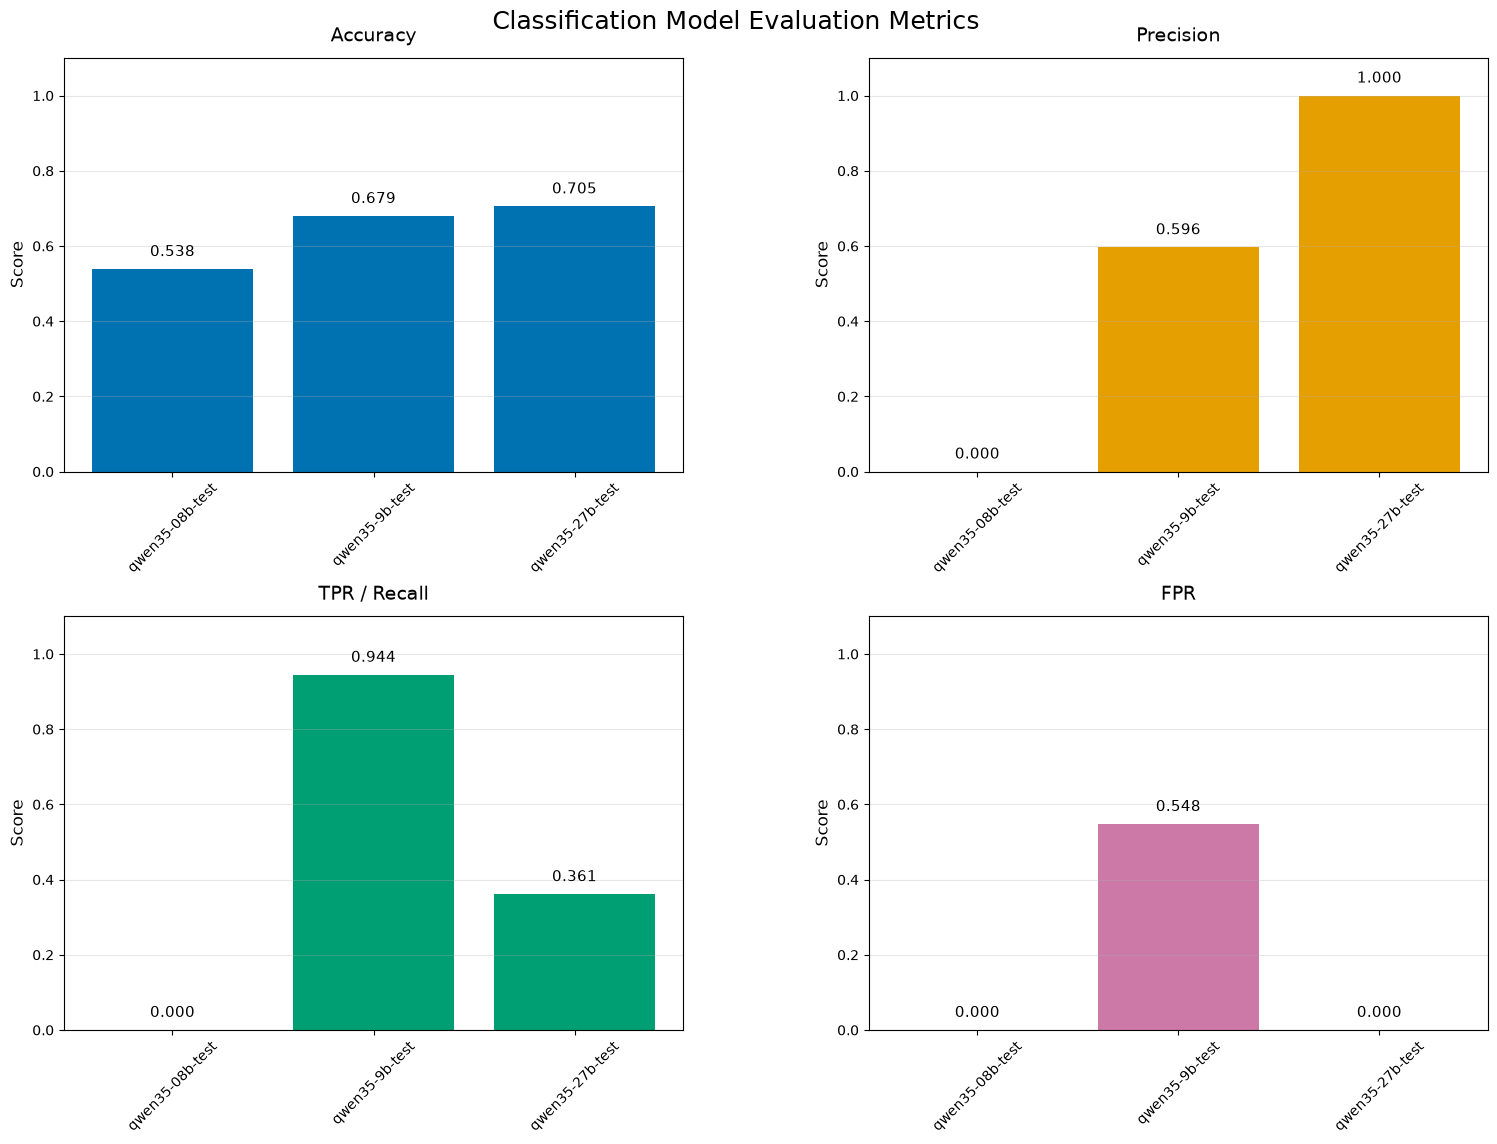

In [12]:
plot_model_metrics([
    "qwen35-08b-test",
    "qwen35-9b-test",
    "qwen35-27b-test",
])

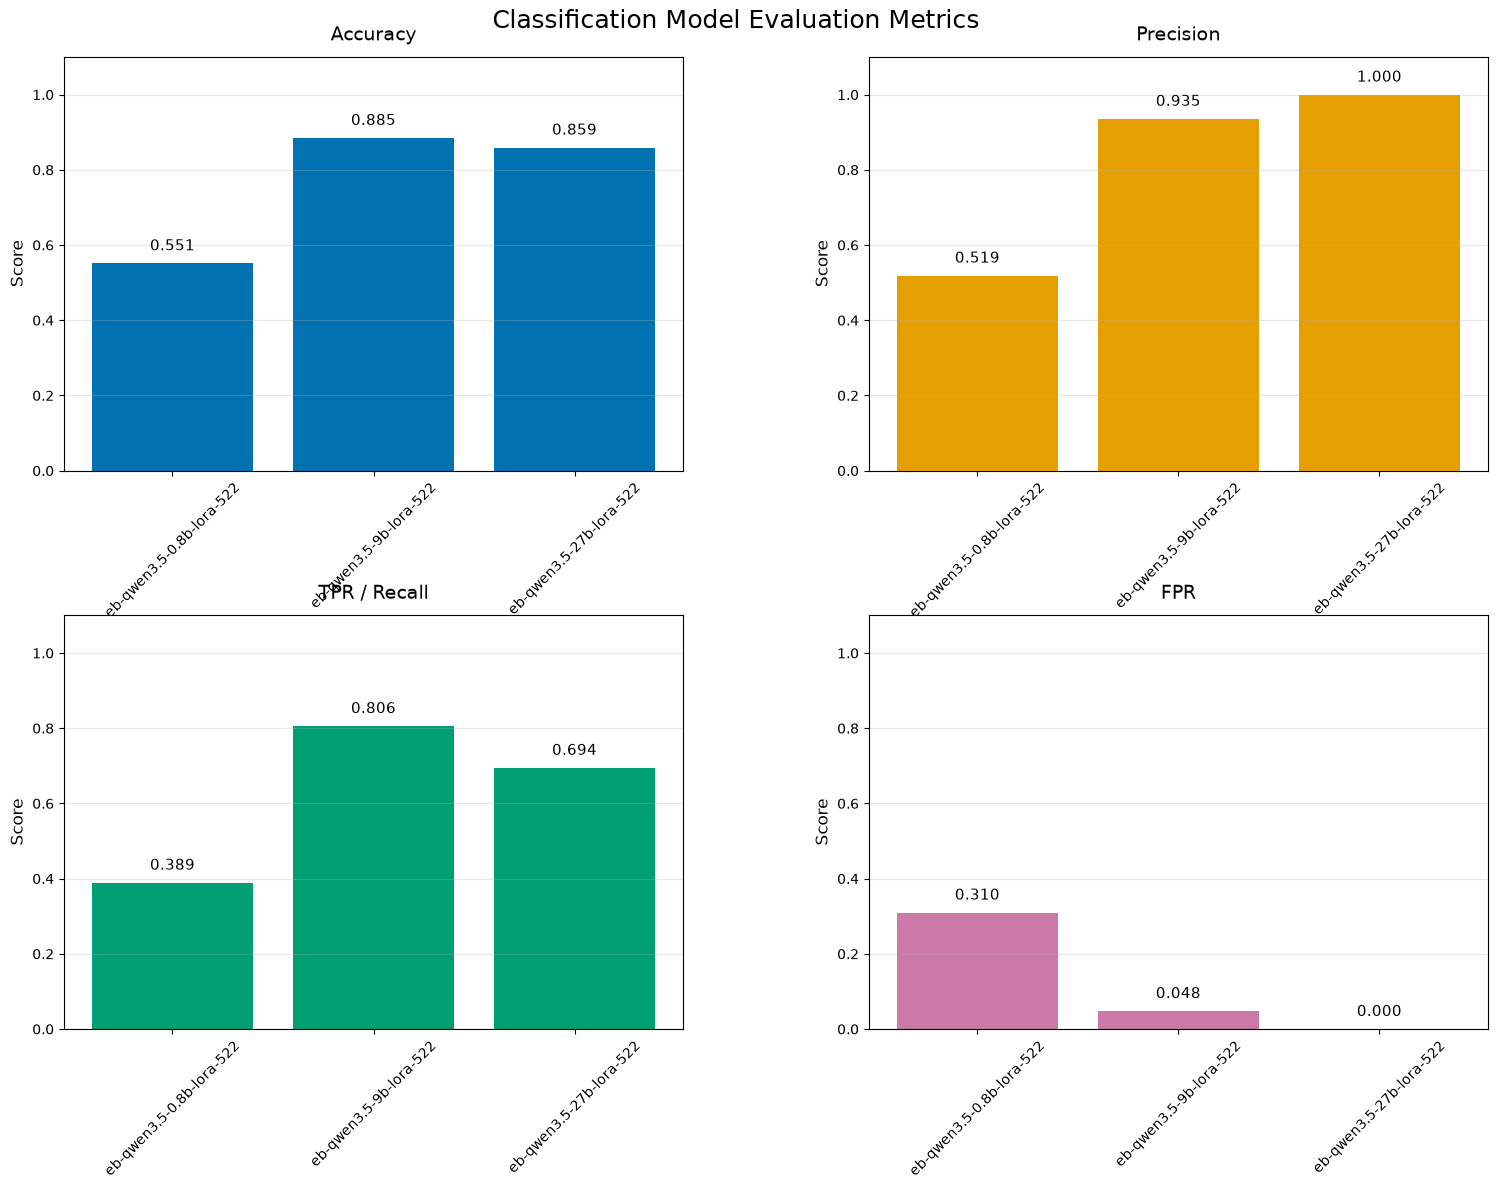

In [4]:
# For fine-tuned models!
plot_model_metrics([
    "eb-qwen3.5-0.8b-lora-522",
    "eb-qwen3.5-9b-lora-522",
    "eb-qwen3.5-27b-lora-522",
])

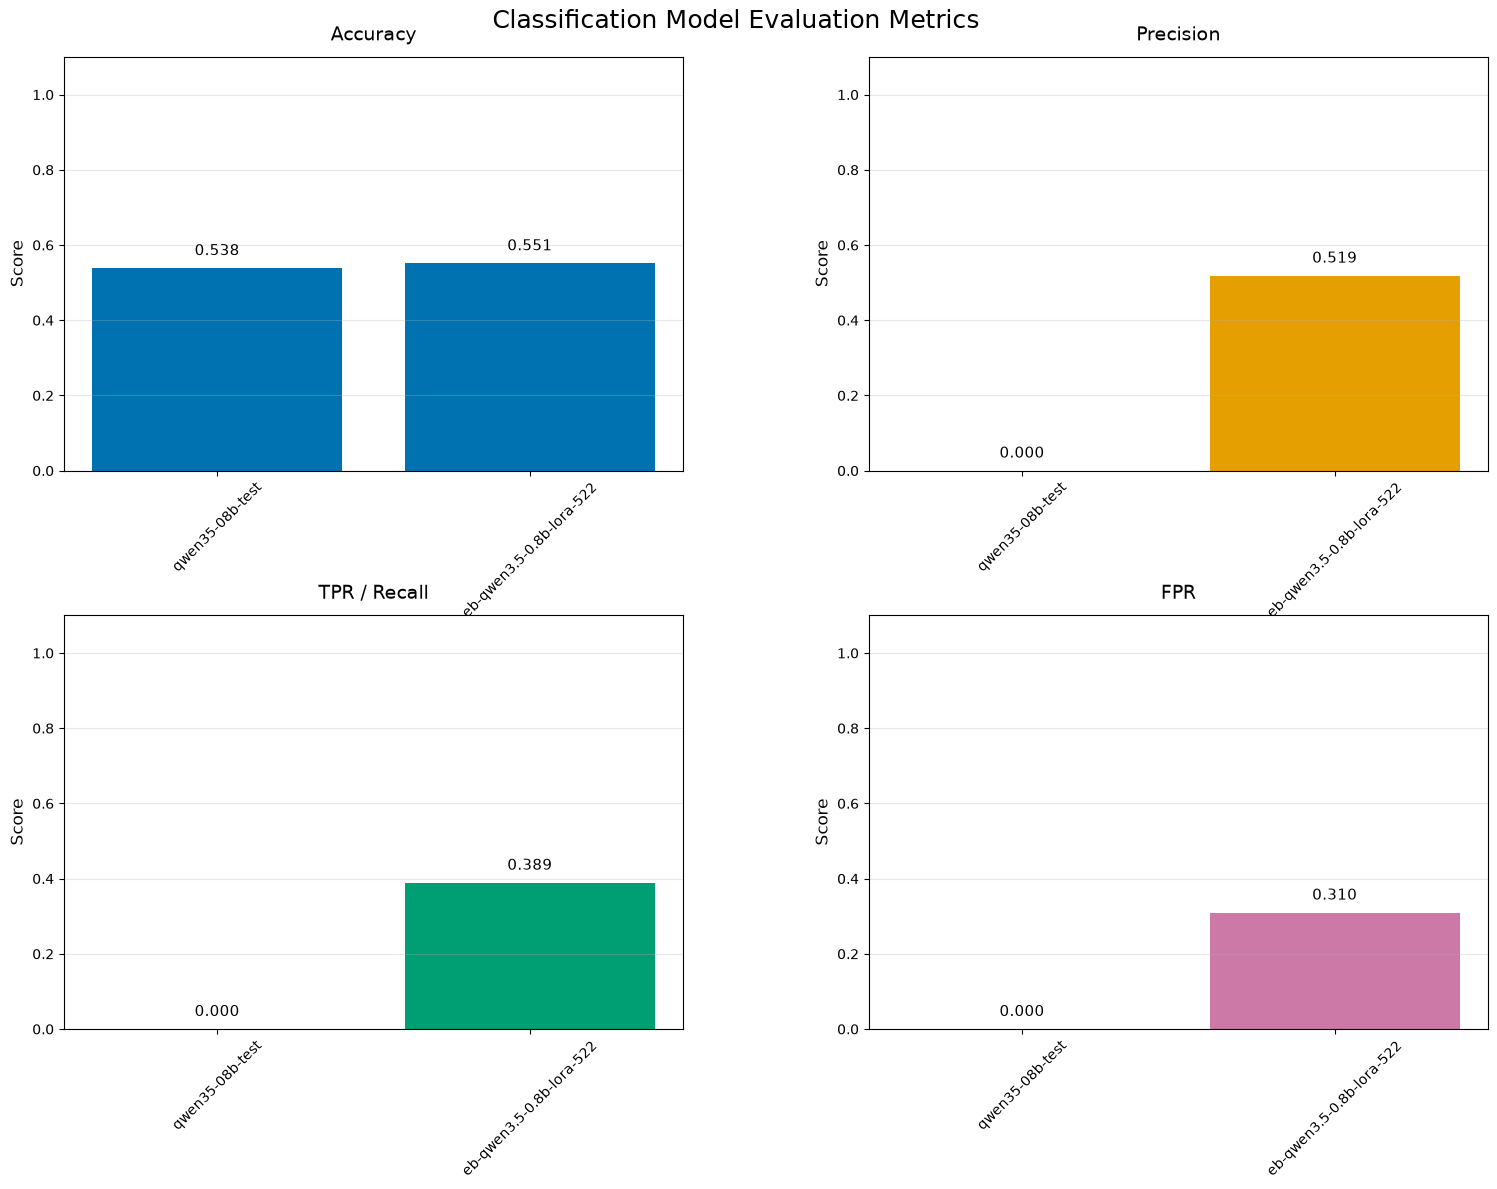

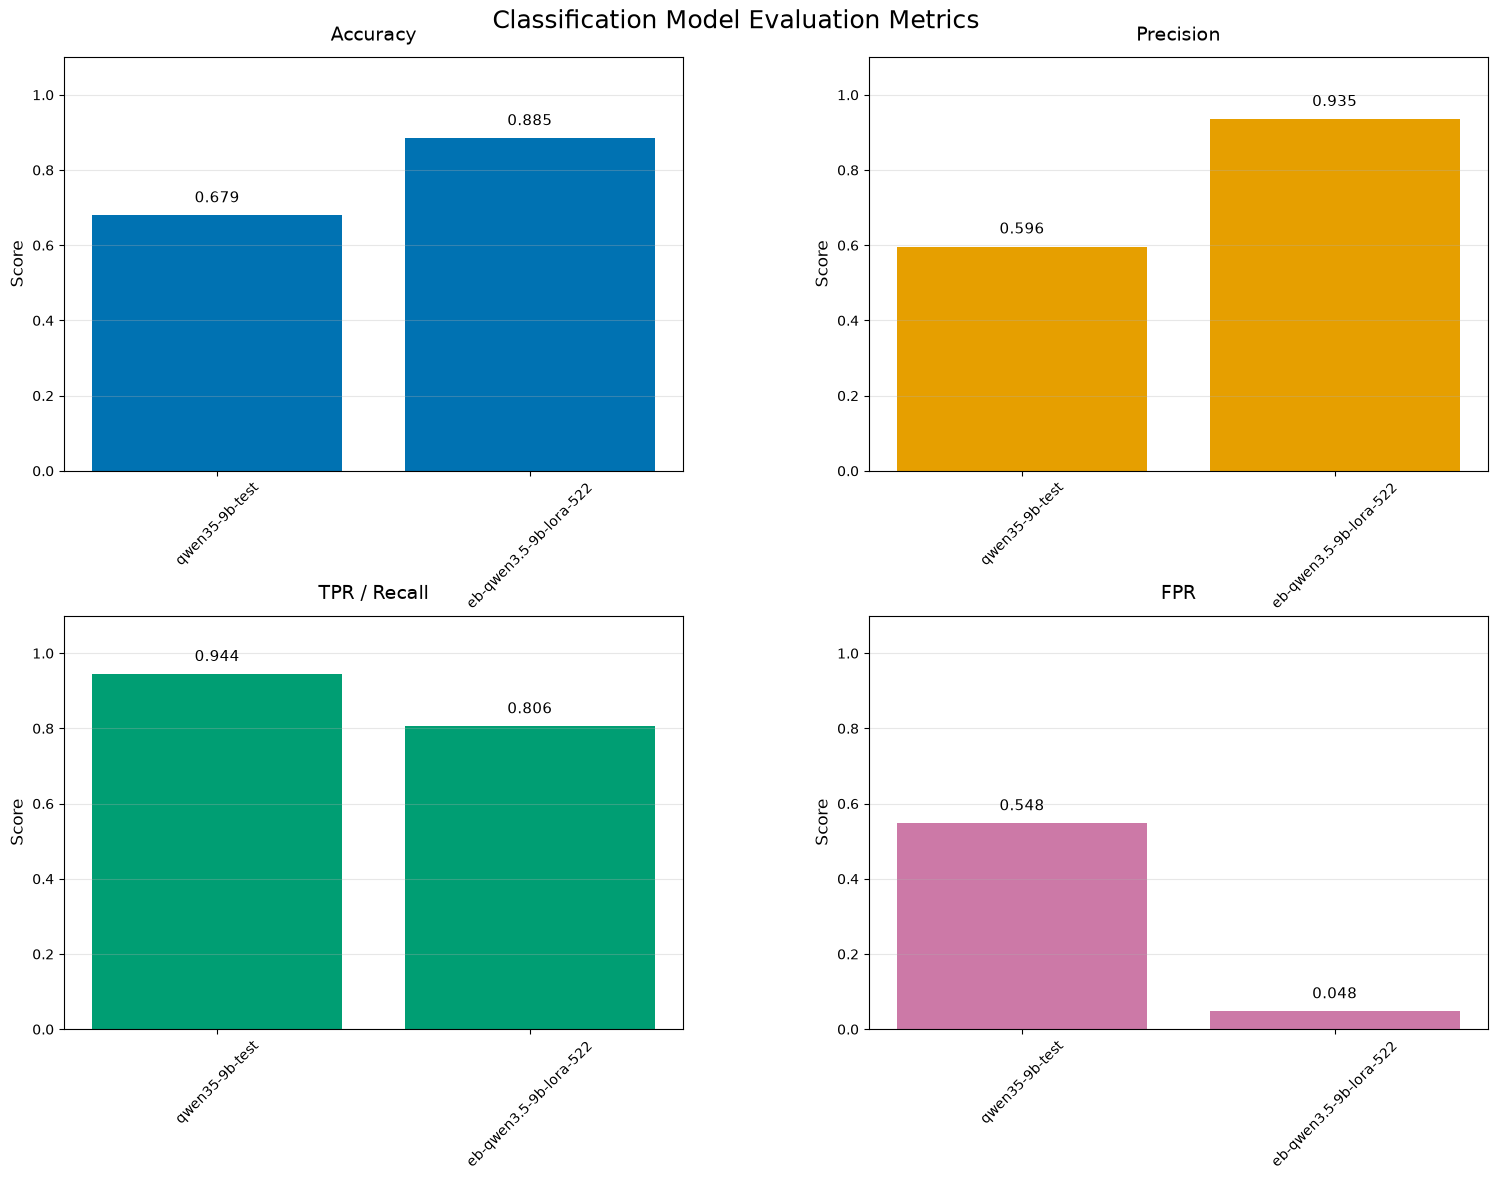

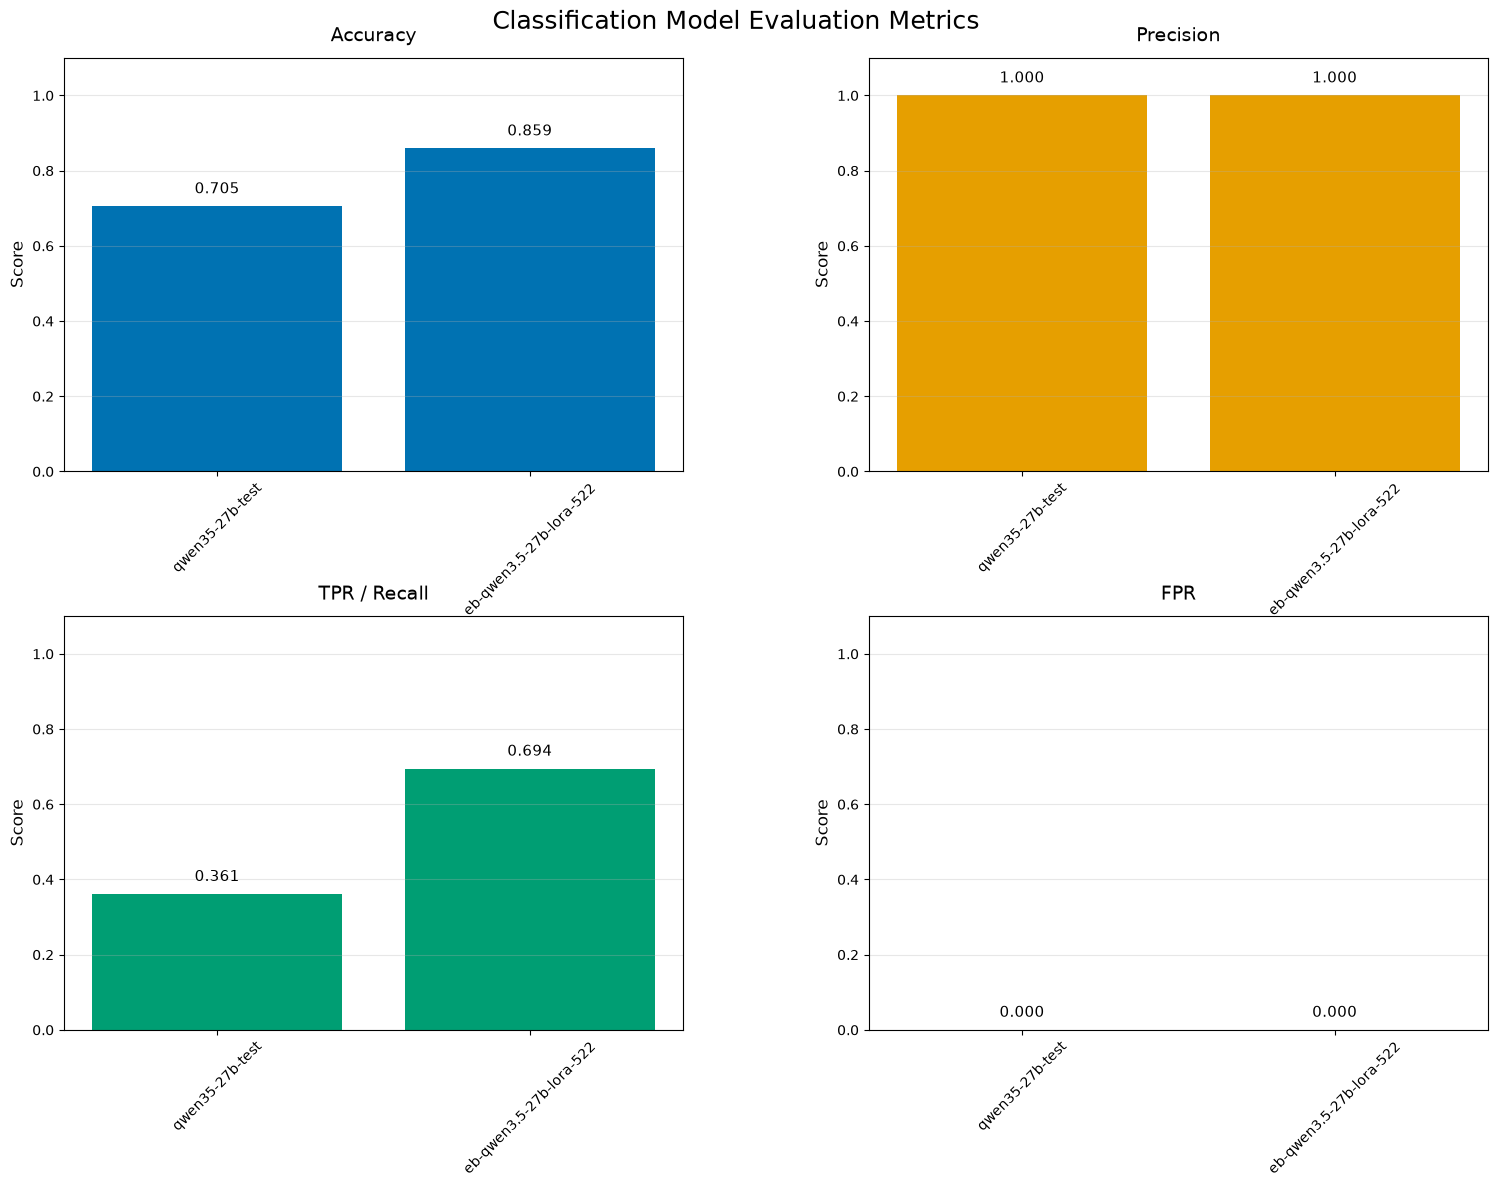

In [5]:
plot_model_metrics([
    "qwen35-08b-test",
    "eb-qwen3.5-0.8b-lora-522",
])
plot_model_metrics([
    "qwen35-9b-test",
    "eb-qwen3.5-9b-lora-522",
])
plot_model_metrics([
    "qwen35-27b-test",
    "eb-qwen3.5-27b-lora-522",
])